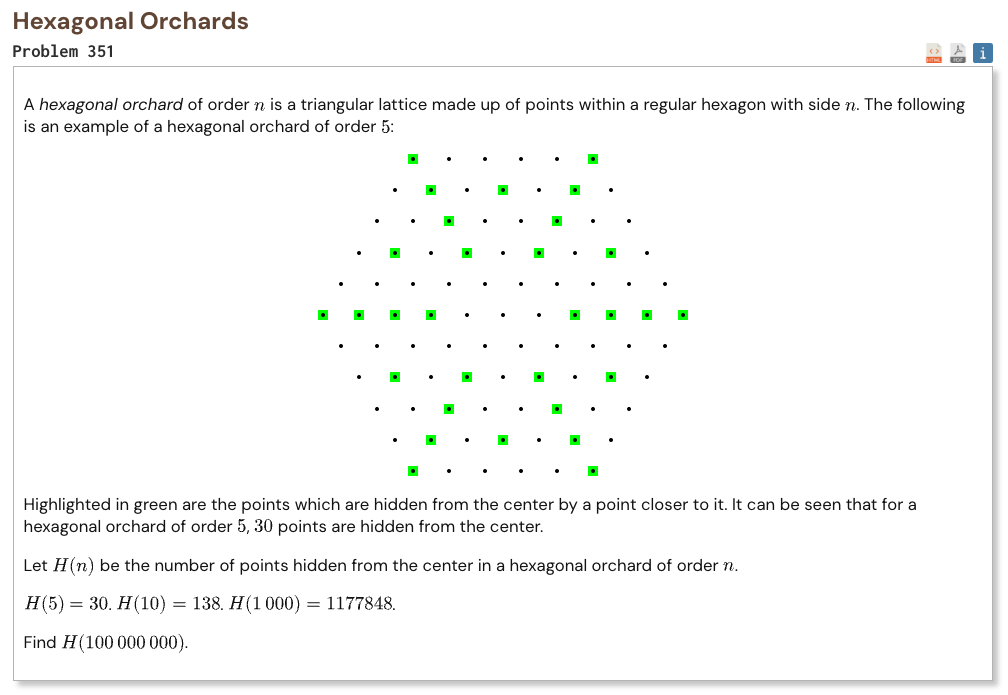

## Initial approach

* count visible points first, then subtract from all orchard points
* every direction from the center corresponds to a reduced lattice vector
* visible points are exactly the vectors with coprime lattice coordinates
* the number of visible points on each hexagonal shell is controlled by Euler’s totient
* total lattice points in the hexagon has a simple quadratic count
* hidden points are total points minus center minus visible points
* compute totients up to the target with a sieve

In [1]:
def totient_sieve(limit):
    phi = list(range(limit + 1))

    for i in range(2, limit + 1):
        if phi[i] == i:
            for j in range(i, limit + 1, i):
                phi[j] -= phi[j] // i

    return phi

def H(n):
    phi = totient_sieve(n)

    visible = 0
    for k in range(1, n + 1):
        visible += phi[k]

    total_points_without_center = 3 * n * (n + 1)
    visible_points = 6 * visible

    return total_points_without_center - visible_points

assert H(5) == 30
assert H(10) == 138
assert H(1000) == 1177848

In [2]:
%%time
result = H(100_000_000)
print("Result:", result)

Result: 11762187201804552
CPU times: user 1min 12s, sys: 1.2 s, total: 1min 14s
Wall time: 1min 14s
